<a href="https://colab.research.google.com/github/Laahir/MAT-422/blob/main/MAT422_HW1_Section_1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laahir/MAT-422/blob/main/HW3/MAT422_HW1_Section_1_4.ipynb)

# MAT 422 - Homework 1 - Section 1.4: SVD, Low-Rank Approximation, and PCA

**Name:** Laahir
**Course:** MAT 422
**Topics covered:** singular value decomposition, low rank matrix approximations, principal component analysis

I'm continuing with examples tied to my job as a Math Instructional Aide: quiz score data for SVD, a synthetic grade pattern grid for the low rank approximation part, and hours studied vs exam score for PCA.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.4.1 Singular Value Decomposition

Any matrix A can be written as `A = U @ Sigma @ V^T`, where U and V have orthonormal columns, and Sigma is diagonal with non-negative entries (the singular values) sorted from largest to smallest.

Here A holds quiz scores for 6 students across 4 quizzes (rows = students, columns = quizzes).

In [3]:
A = np.array([
    [72, 68, 75, 70],
    [88, 85, 90, 92],
    [61, 58, 65, 60],
    [95, 91, 89, 97],
    [77, 74, 80, 78],
    [55, 60, 58, 53],
], dtype=float)

U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(s)

print("shape of A  =", A.shape)
print("shape of U  =", U.shape)
print("singular values (s) =", s)
print("shape of Vt =", Vt.shape)

shape of A  = (6, 4)
shape of U  = (6, 4)
singular values (s) = [371.4469   8.7703   6.6147   2.3506]
shape of Vt = (4, 4)


In [4]:
# check 1: U @ Sigma @ Vt should reconstruct A
reconstruction = U @ Sigma @ Vt
print("reconstructed A =")
print(reconstruction)
print("matches original A?", np.allclose(reconstruction, A))

# check 2: U and V should have orthonormal columns
print("\nU.T @ U close to identity?", np.allclose(U.T @ U, np.eye(U.shape[1])))
print("Vt @ Vt.T close to identity?", np.allclose(Vt @ Vt.T, np.eye(Vt.shape[0])))

reconstructed A =
[[72. 68. 75. 70.]
 [88. 85. 90. 92.]
 [61. 58. 65. 60.]
 [95. 91. 89. 97.]
 [77. 74. 80. 78.]
 [55. 60. 58. 53.]]
matches original A? True

U.T @ U close to identity? True
Vt @ Vt.T close to identity? True


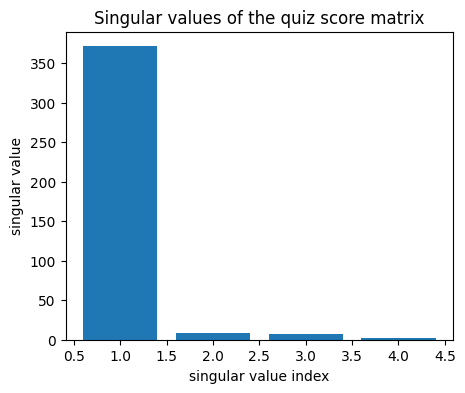

singular values: [371.4469   8.7703   6.6147   2.3506]
first singular value share of total: 0.9544286735782023


In [5]:
plt.figure(figsize=(5, 4))
plt.bar(range(1, len(s) + 1), s, color="tab:blue")
plt.xlabel("singular value index")
plt.ylabel("singular value")
plt.title("Singular values of the quiz score matrix")
plt.show()

print("singular values:", s)
print("first singular value share of total:", s[0] / s.sum())

The first singular value is much bigger than the rest, which tells us most of the "shape" of this data (which students score higher or lower overall across quizzes) is captured by just one dominant direction. The smaller singular values represent finer differences, like a student doing relatively better on one specific quiz.

## 1.4.2 Low-Rank Matrix Approximations

If we only keep the largest k singular values (and their matching columns of U and rows of Vt), we get a rank-k approximation of A. This is useful when A is large but its real structure is simpler than its full size suggests, so we throw away the smallest singular values since they mostly capture noise.

To make this obvious, I'll build a synthetic 20x20 grid that's really just two underlying patterns added together plus a bit of random noise, similar to how a gradebook heatmap might have an overall difficulty trend plus a smaller topic-specific trend.

In [6]:
np.random.seed(7)
rows = np.linspace(0, 1, 20).reshape(-1, 1)
cols = np.linspace(0, 1, 20).reshape(1, -1)

pattern_1 = rows @ cols                 # a smooth "overall difficulty" trend
pattern_2 = np.sin(rows * 3) @ np.cos(cols * 2)  # a smaller wavy trend

A_grid = 3 * pattern_1 + 1.5 * pattern_2 + 0.05 * np.random.randn(20, 20)

U_g, s_g, Vt_g = np.linalg.svd(A_grid, full_matrices=False)
print("singular values (first 6):", s_g[:6])

singular values (first 6): [25.8007  6.2978  0.4075  0.3455  0.3188  0.2879]


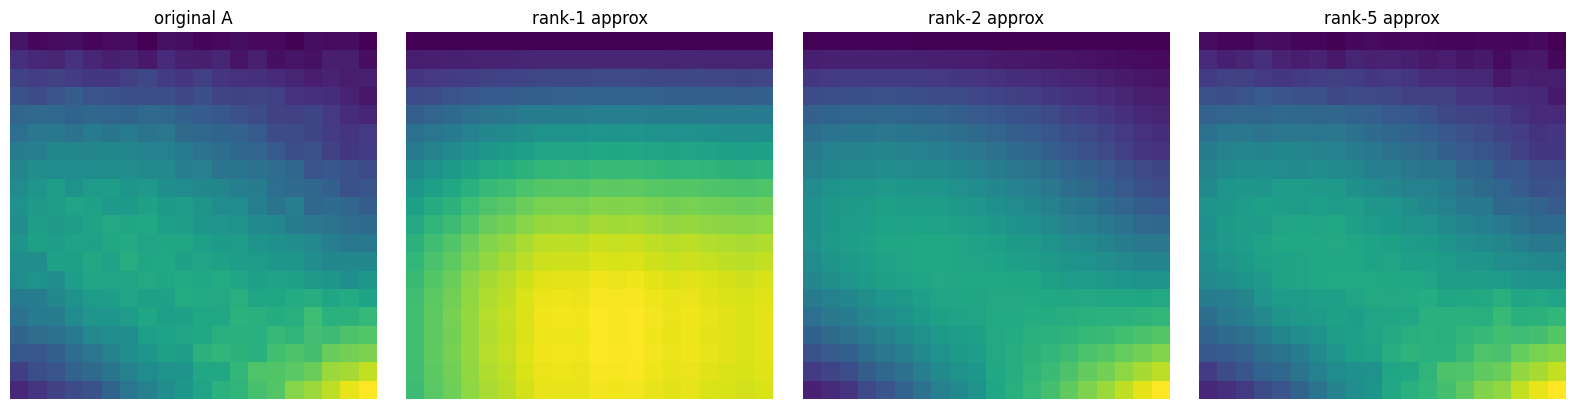

In [7]:
def rank_k_approx(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["original A", "rank-1 approx", "rank-2 approx", "rank-5 approx"]
images = [A_grid, rank_k_approx(U_g, s_g, Vt_g, 1),
          rank_k_approx(U_g, s_g, Vt_g, 2), rank_k_approx(U_g, s_g, Vt_g, 5)]

for ax, title, img in zip(axes, titles, images):
    im = ax.imshow(img, cmap="viridis")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

k = 1: Frobenius error = 6.3623
k = 2: Frobenius error = 0.9039
k = 3: Frobenius error = 0.8069
k = 4: Frobenius error = 0.7292
k = 5: Frobenius error = 0.6558
k = 6: Frobenius error = 0.5892
k = 7: Frobenius error = 0.5214
k = 8: Frobenius error = 0.4651
k = 9: Frobenius error = 0.4067
k = 10: Frobenius error = 0.3489


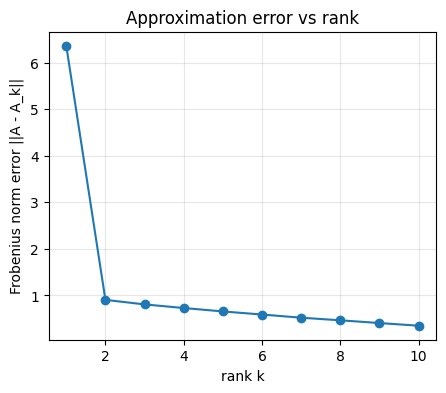

In [8]:
errors = []
ks = list(range(1, 11))
for k in ks:
    A_k = rank_k_approx(U_g, s_g, Vt_g, k)
    error = np.linalg.norm(A_grid - A_k, "fro")
    errors.append(error)
    print(f"k = {k}: Frobenius error = {error:.4f}")

plt.figure(figsize=(5, 4))
plt.plot(ks, errors, marker="o")
plt.xlabel("rank k")
plt.ylabel("Frobenius norm error ||A - A_k||")
plt.title("Approximation error vs rank")
plt.grid(True, alpha=0.3)
plt.show()

The error drops sharply from rank 1 to rank 2, then flattens out. That matches how I built the data, it's really only 2 meaningful patterns plus noise, so a rank-2 approximation already captures almost everything that matters, and adding more rank past that mostly just starts fitting the noise.

## 1.4.3 Principal Component Analysis

PCA finds the directions along which data varies the most. It turns out PCA is really just SVD applied to data after centering it (subtracting the mean of each feature).

Here I'll use hours studied vs exam score for 10 students, two features that are naturally correlated, more hours tends to mean a higher score.

In [9]:
np.random.seed(3)
hours = np.array([2, 3, 4, 4, 5, 6, 6, 7, 8, 9], dtype=float)
scores = 60 + 3.2 * hours + np.random.randn(10) * 2

X = np.column_stack([hours, scores])
X_centered = X - X.mean(axis=0)

print("original data (hours, score):")
print(X)
print("\ncolumn means:", X.mean(axis=0))
print("\ncentered data:")
print(X_centered)

original data (hours, score):
[[ 2.     69.9773]
 [ 3.     70.473 ]
 [ 4.     72.993 ]
 [ 4.     69.073 ]
 [ 5.     75.4452]
 [ 6.     78.4905]
 [ 6.     79.0345]
 [ 7.     81.146 ]
 [ 8.     85.5124]
 [ 9.     87.8456]]

column means: [ 5.4   76.999]

centered data:
[[-3.4    -7.0218]
 [-2.4    -6.526 ]
 [-1.4    -4.006 ]
 [-1.4    -7.926 ]
 [-0.4    -1.5538]
 [ 0.6     1.4914]
 [ 0.6     2.0355]
 [ 1.6     4.147 ]
 [ 2.6     8.5133]
 [ 3.6    10.8465]]


In [10]:
U_x, s_x, Vt_x = np.linalg.svd(X_centered, full_matrices=False)

explained_variance_ratio = (s_x ** 2) / np.sum(s_x ** 2)
print("singular values =", s_x)
print("explained variance ratio =", explained_variance_ratio)
print("\nprincipal directions (rows of Vt):")
print(Vt_x)

# project the centered data onto the principal components
scores_pca = X_centered @ Vt_x.T
print("\nprojected data (PC1, PC2 coordinates):")
print(scores_pca)

singular values = [20.7051  1.6016]
explained variance ratio = [0.9941 0.0059]

principal directions (rows of Vt):
[[ 0.3133  0.9496]
 [-0.9496  0.3133]]

projected data (PC1, PC2 coordinates):
[[-7.7335  1.0287]
 [-6.9494  0.2344]
 [-4.243   0.0743]
 [-7.9656 -1.1539]
 [-1.6009 -0.107 ]
 [ 1.6043 -0.1025]
 [ 2.121   0.068 ]
 [ 4.4395 -0.2201]
 [ 8.8993  0.1984]
 [11.4283 -0.0202]]


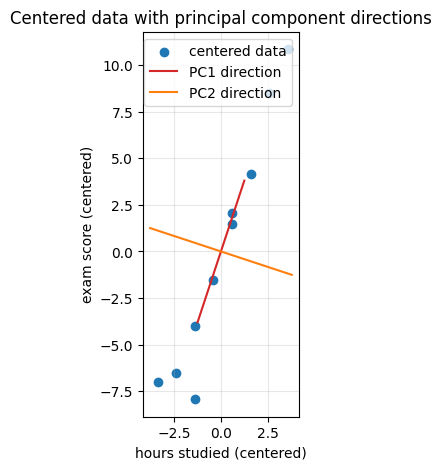

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(X_centered[:, 0], X_centered[:, 1], color="tab:blue", label="centered data")

pc1_direction = Vt_x[0]
scale = 4
plt.plot([-scale * pc1_direction[0], scale * pc1_direction[0]],
         [-scale * pc1_direction[1], scale * pc1_direction[1]],
         color="tab:red", label="PC1 direction")

pc2_direction = Vt_x[1]
plt.plot([-scale * pc2_direction[0], scale * pc2_direction[0]],
         [-scale * pc2_direction[1], scale * pc2_direction[1]],
         color="tab:orange", label="PC2 direction")

plt.xlabel("hours studied (centered)")
plt.ylabel("exam score (centered)")
plt.title("Centered data with principal component directions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

PC1 explains about 99% of the variance here, almost all of the spread in the data happens along one direction, which makes sense since hours studied and exam score move together so closely in this small dataset. PC2 barely matters, it only picks up the small leftover noise around that main trend.

If I had a third feature that was totally unrelated to studying (say, a student's shoe size), PCA would show that as a separate direction with very little explained variance too, since it wouldn't correlate with the main pattern.

## Reflection and Submission Checklist

- I explained each concept in my own words before showing the code.
- I checked my claims numerically instead of just trusting the math (reconstruction matching A, U and V having orthonormal columns, the Frobenius error shrinking as rank increases, explained variance ratios summing to 1).
- I used personal examples tied to my job as a Math Instructional Aide (quiz scores, a synthetic grade-pattern grid, hours studied vs exam score) instead of a generic textbook dataset.
- I ran every cell top to bottom in Colab with no errors.
- I saved this notebook directly from Google Colab to GitHub so the Open in Colab badge works.